In [2]:
import pandas as pd
import glob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [23]:
files = [
    '../data/kaggle/CEAS_08.csv',
    '../data/kaggle/Enron.csv',
    '../data/kaggle/Ling.csv',
    '../data/kaggle/Nazario.csv',
    '../data/kaggle/Nigerian_Fraud.csv',
    '../data/kaggle/phishing_email.csv',
    '../data/kaggle/SpamAssasin.csv'
]

frames = []
for file in files:
    df = pd.read_csv(file)
    if 'text_combined' in df.columns:
        df = df[['text_combined', 'label']].rename(columns={'text_combined': 'text'})
    elif 'subject' in df.columns and 'body' in df.columns:
        df['text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')
        df = df[['text', 'label']]
    df = df.dropna()
    frames.append(df)

# Combine all into one DataFrame
merged_df = pd.concat(frames, ignore_index=True)

# Optional: Normalize label (0 = ham, 1 = spam)
merged_df['label'] = merged_df['label'].map({0: 'ham', 1: 'spam'})

# Inspect balance
merged_df['label'].value_counts()

label
spam    85782
ham     79190
Name: count, dtype: int64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    merged_df['text'], merged_df['label'],
    test_size=0.2,
    stratify=merged_df['label'],
    random_state=42
)

In [25]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

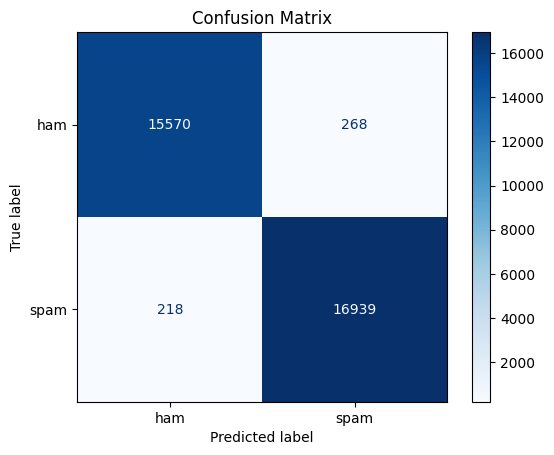

Accuracy: 0.9852704955296258

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      0.98      0.98     15838
        spam       0.98      0.99      0.99     17157

    accuracy                           0.99     32995
   macro avg       0.99      0.99      0.99     32995
weighted avg       0.99      0.99      0.99     32995



In [26]:
y_pred = model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [27]:
sample = [
    "Want to see naked pictures of me?",
    "Please submit your timesheet",
    "You won a free gift card!",
    "Subject: meeting at 3pm today",
    "what up brodie",
    "Hey John we will conduct on interview at 4:00 pm PST",
]
sample_vec = vectorizer.transform(sample)
preds = model.predict(sample_vec)

for msg, label in zip(sample, preds):
    print(f"> {msg} → {label}")


> Want to see naked pictures of me? → spam
> Please submit your timesheet → spam
> You won a free gift card! → spam
> Subject: meeting at 3pm today → ham
> what up brodie → spam
> Hey John we will conduct on interview at 4:00 pm PST → ham


In [30]:
import joblib
joblib.dump(model, '../app/model.pkl')
joblib.dump(vectorizer, '../app/vectorizer.pkl')


['../app/vectorizer.pkl']

In [18]:
#trying the data if we choose 80% from each dataset rather than aggreating then choosing randomly

In [19]:
train_frames = []
test_frames = []

for file in files:
    df = pd.read_csv(file)
    if 'text_combined' in df.columns:
        df = df[['text_combined', 'label']].rename(columns={'text_combined': 'text'})
    elif 'subject' in df.columns and 'body' in df.columns:
        df['text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')
        df = df[['text', 'label']]
    df = df.dropna()
    df['label'] = df['label'].map({0: 'ham', 1: 'spam'})
    train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
    train_frames.append(train_df)
    test_frames.append(test_df)

# Combine all train and test splits
train_df = pd.concat(train_frames, ignore_index=True)
test_df = pd.concat(test_frames, ignore_index=True)

In [20]:
X_train = train_df['text']
y_train = train_df['label']
X_test = test_df['text']
y_test = test_df['label']

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

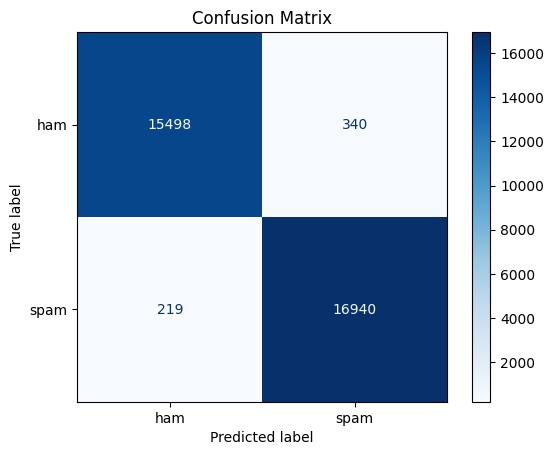

Accuracy: 0.9830590659756948

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      0.98      0.98     15838
        spam       0.98      0.99      0.98     17159

    accuracy                           0.98     32997
   macro avg       0.98      0.98      0.98     32997
weighted avg       0.98      0.98      0.98     32997



In [22]:
y_pred = model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

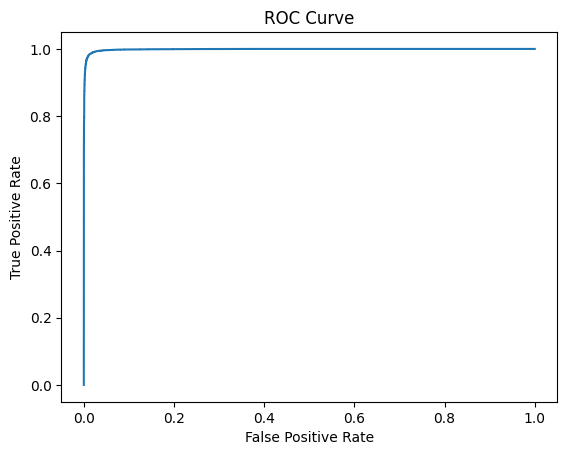

AUC Score: 0.9987221829716207


In [31]:
from sklearn.metrics import roc_auc_score, roc_curve

y_scores = model.predict_proba(X_test_vec)[:, 1]  # get prob for 'spam'
fpr, tpr, _ = roc_curve((y_test == "spam"), y_scores)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score((y_test == "spam"), y_scores))
